# Neural Network Investigation Using KNMI Weather Data

This notebook investigates whether a neural network can learn patterns from the KNMI weather dataset.

The original goal is to investigate whether offshore wind power production can be predicted using neural networks. However, the uploaded dataset only contains KNMI weather data and does not contain a real power production column. Because of that, this notebook uses **wind gust speed** as a proof-of-concept target.

This still demonstrates the full modelling process:
- loading the preprocessed KNMI data
- creating time-based features
- selecting weather features
- splitting the data into train and test sets
- scaling numerical features
- training a baseline model
- training a neural network
- comparing predictions with actual values

If a merged weather + power production dataset is available, the target column can be changed to the actual power production column.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Load the dataset

The dataset used here is the cleaned KNMI weather dataset from Sprint 2.

In [2]:
DATA_PATH = Path("../data/knmi_combined_2015plus_preprocessed.csv")

weather = pd.read_csv(DATA_PATH)

print("Shape:", weather.shape)
weather.head()

Shape: (686424, 23)


,timestamp,Station,Station_ID,Source_Period,Source_File,wind_direction_deg,wind_direction_interpolated_deg,wind_dir_sin,wind_dir_cos,wind_speed_ms,...,min_temp_10cm_c,dew_point_c,sunshine_duration_h,global_radiation_j_cm2,precip_duration_h,precipitation_mm,pressure_hpa,visibility_code,cloud_cover_octants,humidity_pct
0,1/1/2015 0:00,Valkenburg,210,2011-2020,Valkenburg_210_2011-2020.txt,210.0,210.0,-0.500000,-0.866025,4.0,...,1.0,1.2,0.0,0.0,0.0,0.0,1033.7,37.0,0.0,87.0
1,1/1/2015 1:00,Valkenburg,210,2011-2020,Valkenburg_210_2011-2020.txt,210.0,210.0,-0.500000,-0.866025,4.0,...,1.0,0.8,0.0,0.0,0.0,0.0,1033.5,57.0,0.0,85.0
2,1/1/2015 2:00,Valkenburg,210,2011-2020,Valkenburg_210_2011-2020.txt,200.0,200.0,-0.342020,-0.939693,5.0,...,1.0,0.4,0.0,0.0,0.0,0.0,1032.9,60.0,0.0,85.0
3,1/1/2015 3:00,Valkenburg,210,2011-2020,Valkenburg_210_2011-2020.txt,210.0,210.0,-0.500000,-0.866025,4.0,...,1.0,0.5,0.0,0.0,0.0,0.0,1033.9,61.0,0.0,85.0
4,1/1/2015 4:00,Valkenburg,210,2011-2020,Valkenburg_210_2011-2020.txt,190.0,190.0,-0.173648,-0.984808,5.0,...,1.0,0.5,0.0,0.0,0.0,0.0,1032.9,60.0,2.0,88.0


## 2. Check columns and missing values

Before training a model, I checked what columns are available and whether there are missing values. This is important because neural networks cannot work directly with missing or badly formatted data.

In [3]:
display(weather.dtypes)
display(weather.isna().sum().sort_values(ascending=False).head(15))

timestamp                              str
Station                                str
Station_ID                           int64
Source_Period                          str
Source_File                            str
wind_direction_deg                 float64
wind_direction_interpolated_deg    float64
wind_dir_sin                       float64
wind_dir_cos                       float64
wind_speed_ms                      float64
wind_speed_10min_ms                float64
wind_gust_ms                       float64
temperature_c                      float64
min_temp_10cm_c                    float64
dew_point_c                        float64
sunshine_duration_h                float64
global_radiation_j_cm2             float64
precip_duration_h                  float64
precipitation_mm                   float64
pressure_hpa                       float64
visibility_code                    float64
cloud_cover_octants                float64
humidity_pct                       float64
dtype: obje

cloud_cover_octants                374472
visibility_code                    274392
global_radiation_j_cm2             100080
sunshine_duration_h                100080
pressure_hpa                       100080
wind_direction_deg                   3186
Station                                 0
wind_direction_interpolated_deg         0
Source_File                             0
Source_Period                           0
Station_ID                              0
timestamp                               0
wind_dir_sin                            0
wind_speed_ms                           0
wind_dir_cos                            0
dtype: int64

## 3. Create time-based features

The timestamp column is converted into separate time features. These can help the model learn patterns based on hour, month, and season.

In [4]:
weather["timestamp"] = pd.to_datetime(weather["timestamp"], errors="coerce")
weather = weather.dropna(subset=["timestamp"])

weather["hour"] = weather["timestamp"].dt.hour
weather["month"] = weather["timestamp"].dt.month
weather["day_of_year"] = weather["timestamp"].dt.dayofyear

weather[["timestamp", "hour", "month", "day_of_year"]].head()

,timestamp,hour,month,day_of_year
0,2015-01-01 00:00:00,0,1,1
1,2015-01-01 01:00:00,1,1,1
2,2015-01-01 02:00:00,2,1,1
3,2015-01-01 03:00:00,3,1,1
4,2015-01-01 04:00:00,4,1,1


## 4. Choose target and input features

Because this uploaded dataset does not include actual power production, I used `wind_gust_ms` as the prediction target. This gives evidence that I investigated how neural networks can be applied to the weather dataset.

For the real project, if a merged power production column is added later, only the target column needs to be changed.

In [5]:
# For the real merged dataset, this could be changed to something like:
# TARGET_COLUMN = "power_mw"

TARGET_COLUMN = "wind_gust_ms"

feature_columns = [
    "Station",
    "Station_ID",
    "wind_direction_interpolated_deg",
    "wind_dir_sin",
    "wind_dir_cos",
    "wind_speed_ms",
    "wind_speed_10min_ms",
    "temperature_c",
    "dew_point_c",
    "sunshine_duration_h",
    "global_radiation_j_cm2",
    "precip_duration_h",
    "precipitation_mm",
    "pressure_hpa",
    "visibility_code",
    "cloud_cover_octants",
    "humidity_pct",
    "hour",
    "month",
    "day_of_year"
]

existing_features = [col for col in feature_columns if col in weather.columns]

model_data = weather[existing_features + [TARGET_COLUMN]].dropna(subset=[TARGET_COLUMN])

print("Target column:", TARGET_COLUMN)
print("Number of features:", len(existing_features))
print("Rows available for modelling:", len(model_data))

Target column: wind_gust_ms
Number of features: 20
Rows available for modelling: 686424


## 5. Use a sample for faster training

The full dataset is large, so I used a random sample. This makes the notebook easier to run during a demo while still keeping enough data for the model to learn patterns.

In [6]:
model_data = model_data.sample(n=min(50000, len(model_data)), random_state=42)

X = model_data[existing_features]
y = model_data[TARGET_COLUMN]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 20)
y shape: (50000,)


## 6. Train/test split and preprocessing

The data is split into training and testing data. Numerical columns are filled with the median and scaled using `StandardScaler`. The station name is categorical, so it is encoded using `OneHotEncoder`.

In [7]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Numeric features: ['Station_ID', 'wind_direction_interpolated_deg', 'wind_dir_sin', 'wind_dir_cos', 'wind_speed_ms', 'wind_speed_10min_ms', 'temperature_c', 'dew_point_c', 'sunshine_duration_h', 'global_radiation_j_cm2', 'precip_duration_h', 'precipitation_mm', 'pressure_hpa', 'visibility_code', 'cloud_cover_octants', 'humidity_pct', 'hour', 'month', 'day_of_year']
Categorical features: ['Station']
Training rows: 40000
Testing rows: 10000


## 7. Baseline model

A baseline model is trained first. This model simply predicts the average target value. The neural network should perform better than this to show that it has learned something useful.

In [8]:
baseline_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)

## 8. Neural network model

The neural network used here is an `MLPRegressor`. It has two hidden layers: one with 64 neurons and one with 32 neurons. Early stopping is used so the model can stop training when it no longer improves.

In [9]:
neural_network_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=42,
        early_stopping=True
    ))
])

neural_network_model.fit(X_train, y_train)
nn_predictions = neural_network_model.predict(X_test)

## 9. Evaluate the models

The models are compared using:

- **MAE**: average absolute prediction error
- **RMSE**: gives more weight to larger errors
- **R²**: shows how much of the variation is explained by the model

In [10]:
def evaluate_model(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted) ** 0.5
    r2 = r2_score(actual, predicted)
    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results = pd.DataFrame([
    evaluate_model("Baseline mean model", y_test, baseline_predictions),
    evaluate_model("Neural network MLPRegressor", y_test, nn_predictions)
])

display(results)

Path("../results").mkdir(exist_ok=True)
results.to_csv("../results/model_results.csv", index=False)

,Model,MAE,RMSE,R2
0,Baseline mean model,3.424061,4.349035,-0.000118
1,Neural network MLPRegressor,0.657807,0.887927,0.958311


## 10. Actual vs predicted plot

This scatter plot compares the neural network predictions with the real target values. If the model is good, the points should roughly follow a diagonal pattern.

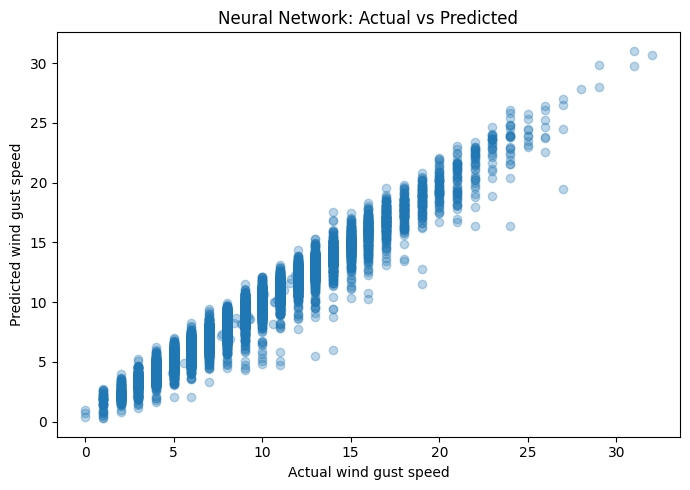

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, nn_predictions, alpha=0.3)
plt.xlabel("Actual wind gust speed")
plt.ylabel("Predicted wind gust speed")
plt.title("Neural Network: Actual vs Predicted")
plt.tight_layout()
plt.savefig("../results/actual_vs_predicted.png", dpi=150)
plt.show()

## 11. First 100 predictions

This plot compares the first 100 actual values with the first 100 neural network predictions. It gives a simple visual check of whether the model follows the same general pattern.

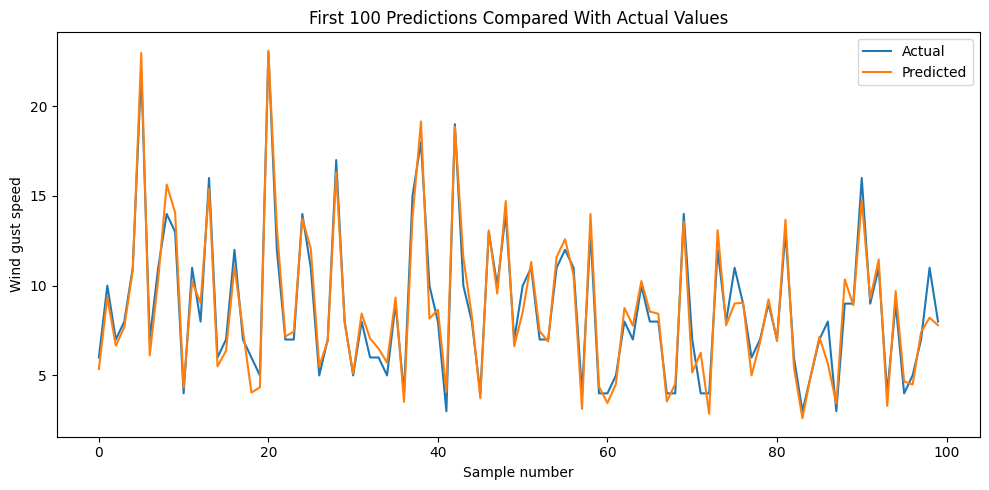

In [12]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:100],
    "Predicted": nn_predictions[:100]
})

plt.figure(figsize=(10, 5))
plt.plot(comparison["Actual"].values, label="Actual")
plt.plot(comparison["Predicted"].values, label="Predicted")
plt.xlabel("Sample number")
plt.ylabel("Wind gust speed")
plt.title("First 100 Predictions Compared With Actual Values")
plt.legend()
plt.tight_layout()
plt.savefig("../results/first_100_predictions.png", dpi=150)
plt.show()

## 12. Short conclusion for the sprint

A neural network was investigated as a possible method for forecasting wind-related outcomes from KNMI weather data. Since the current uploaded dataset does not contain actual offshore power production values, wind gust speed was used as a proof-of-concept target. The model used weather inputs such as wind speed, wind direction, temperature, humidity, pressure, precipitation, cloud cover, and time-based features. A baseline mean model was trained first, then compared with an MLPRegressor neural network. This allowed me to test the full neural-network workflow, including preprocessing, scaling, training, prediction, and evaluation using MAE, RMSE, and R².

For the next step, the same structure can be reused with a merged dataset where the target column is actual offshore wind power production. This would make the investigation directly focused on predicting generated power instead of only predicting wind conditions.